# EDA — World Happiness Report (2015–2019)
**Course:** ETL (G01) — Workshop 3  
**Goal:** Perform exploratory data analysis on all datasets before cleaning and harmonization.

## 1. Imports and Configuration

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Plot styling
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (12, 5)

# Display all columns in pandas
pd.set_option('display.max_columns', None)

## 2. Load Raw Datasets

In [2]:
# ------------------------------------------------------------------
# Load each year from the raw folder
# Replace these paths with your local paths if needed
# ------------------------------------------------------------------
df_2015 = pd.read_csv('../data/raw/2015.csv')
df_2016 = pd.read_csv('../data/raw/2016.csv')
df_2017 = pd.read_csv('../data/raw/2017.csv')
df_2018 = pd.read_csv('../data/raw/2018.csv')
df_2019 = pd.read_csv('../data/raw/2019.csv')

# Group them for iteration
datasets = {
    '2015': df_2015,
    '2016': df_2016,
    '2017': df_2017,
    '2018': df_2018,
    '2019': df_2019,
}

print('Datasets loaded successfully.')

Datasets loaded successfully.


## 3. Schema Comparison Across Years

In [3]:
# ------------------------------------------------------------------
# Print columns for each year to spot schema differences
# ------------------------------------------------------------------
for year, df in datasets.items():
    print(f'--- {year} | shape: {df.shape} ---')
    print(df.columns.tolist())
    print()

--- 2015 | shape: (158, 12) ---
['Country', 'Region', 'Happiness Rank', 'Happiness Score', 'Standard Error', 'Economy (GDP per Capita)', 'Family', 'Health (Life Expectancy)', 'Freedom', 'Trust (Government Corruption)', 'Generosity', 'Dystopia Residual']

--- 2016 | shape: (157, 13) ---
['Country', 'Region', 'Happiness Rank', 'Happiness Score', 'Lower Confidence Interval', 'Upper Confidence Interval', 'Economy (GDP per Capita)', 'Family', 'Health (Life Expectancy)', 'Freedom', 'Trust (Government Corruption)', 'Generosity', 'Dystopia Residual']

--- 2017 | shape: (155, 12) ---
['Country', 'Happiness.Rank', 'Happiness.Score', 'Whisker.high', 'Whisker.low', 'Economy..GDP.per.Capita.', 'Family', 'Health..Life.Expectancy.', 'Freedom', 'Generosity', 'Trust..Government.Corruption.', 'Dystopia.Residual']

--- 2018 | shape: (156, 9) ---
['Overall rank', 'Country or region', 'Score', 'GDP per capita', 'Social support', 'Healthy life expectancy', 'Freedom to make life choices', 'Generosity', 'Perc

### Observations — Schema differences

| Year | Column name for country | Column name for happiness score | Has Region | Extra columns |
|------|------------------------|---------------------------------|------------|---------------|
| 2015 | `Country` | `Happiness Score` | ✅ Yes | `Standard Error`, `Dystopia Residual` |
| 2016 | `Country` | `Happiness Score` | ✅ Yes | `Lower/Upper Confidence Interval`, `Dystopia Residual` |
| 2017 | `Country` | `Happiness.Score` | ❌ No | `Whisker.high`, `Whisker.low`, `Dystopia.Residual` |
| 2018 | `Country or region` | `Score` | ❌ No | `Overall rank` |
| 2019 | `Country or region` | `Score` | ❌ No | `Overall rank` |

**Key issues to fix in cleaning:**
- Different column names for the same concept (country, score, GDP, health, family, corruption)
- 2015 uses dot notation (`Happiness.Score`)
- `Region` column only present in 2015 and 2016
- 2018 has 1 null value in `Perceptions of corruption`

## 4. Shape and Basic Info

In [4]:
# ------------------------------------------------------------------
# Shape summary for all years
# ------------------------------------------------------------------
summary = pd.DataFrame({
    'year': list(datasets.keys()),
    'rows': [df.shape[0] for df in datasets.values()],
    'columns': [df.shape[1] for df in datasets.values()],
})

display(summary)

,year,rows,columns
0,2015,158,12
1,2016,157,13
2,2017,155,12
3,2018,156,9
4,2019,156,9


In [5]:
# ------------------------------------------------------------------
# Detailed info for each dataset
# ------------------------------------------------------------------
for year, df in datasets.items():
    print(f'\n========== {year} ==========')
    display(df.head(3))
    print(df.dtypes)


========== 2015 ==========


,Country,Region,Happiness Rank,Happiness Score,Standard Error,Economy (GDP per Capita),Family,Health (Life Expectancy),Freedom,Trust (Government Corruption),Generosity,Dystopia Residual
0,Switzerland,Western Europe,1,7.587,0.03411,1.39651,1.34951,0.94143,0.66557,0.41978,0.29678,2.51738
1,Iceland,Western Europe,2,7.561,0.04884,1.30232,1.40223,0.94784,0.62877,0.14145,0.43630,2.70201
2,Denmark,Western Europe,3,7.527,0.03328,1.32548,1.36058,0.87464,0.64938,0.48357,0.34139,2.49204


Country                              str
Region                               str
Happiness Rank                     int64
Happiness Score                  float64
Standard Error                   float64
Economy (GDP per Capita)         float64
Family                           float64
Health (Life Expectancy)         float64
Freedom                          float64
Trust (Government Corruption)    float64
Generosity                       float64
Dystopia Residual                float64
dtype: object

========== 2016 ==========


,Country,Region,Happiness Rank,Happiness Score,Lower Confidence Interval,Upper Confidence Interval,Economy (GDP per Capita),Family,Health (Life Expectancy),Freedom,Trust (Government Corruption),Generosity,Dystopia Residual
0,Denmark,Western Europe,1,7.526,7.460,7.592,1.44178,1.16374,0.79504,0.57941,0.44453,0.36171,2.73939
1,Switzerland,Western Europe,2,7.509,7.428,7.590,1.52733,1.14524,0.86303,0.58557,0.41203,0.28083,2.69463
2,Iceland,Western Europe,3,7.501,7.333,7.669,1.42666,1.18326,0.86733,0.56624,0.14975,0.47678,2.83137


Country                              str
Region                               str
Happiness Rank                     int64
Happiness Score                  float64
Lower Confidence Interval        float64
Upper Confidence Interval        float64
Economy (GDP per Capita)         float64
Family                           float64
Health (Life Expectancy)         float64
Freedom                          float64
Trust (Government Corruption)    float64
Generosity                       float64
Dystopia Residual                float64
dtype: object

========== 2017 ==========


...

Country                              str
Happiness.Rank                     int64
Happiness.Score                  float64
Whisker.high                     float64
Whisker.low                      float64
Economy..GDP.per.Capita.         float64
Family                           float64
Health..Life.Expectancy.         float64
Freedom                          float64
Generosity                       float64
Trust..Government.Corruption.    float64
Dystopia.Residual                float64
dtype: object

========== 2018 ==========


,Overall rank,Country or region,Score,GDP per capita,Social support,Healthy life expectancy,Freedom to make life choices,Generosity,Perceptions of corruption
0,1,Finland,7.632,1.305,1.592,0.874,0.681,0.202,0.393
1,2,Norway,7.594,1.456,1.582,0.861,0.686,0.286,0.340
2,3,Denmark,7.555,1.351,1.590,0.868,0.683,0.284,0.408


Overall rank                      int64
Country or region                   str
Score                           float64
GDP per capita                  float64
Social support                  float64
Healthy life expectancy         float64
Freedom to make life choices    float64
Generosity                      float64
Perceptions of corruption       float64
dtype: object

========== 2019 ==========


,Overall rank,Country or region,Score,GDP per capita,Social support,Healthy life expectancy,Freedom to make life choices,Generosity,Perceptions of corruption
0,1,Finland,7.769,1.340,1.587,0.986,0.596,0.153,0.393
1,2,Denmark,7.600,1.383,1.573,0.996,0.592,0.252,0.410
2,3,Norway,7.554,1.488,1.582,1.028,0.603,0.271,0.341


Overall rank                      int64
Country or region                   str
Score                           float64
GDP per capita                  float64
Social support                  float64
Healthy life expectancy         float64
Freedom to make life choices    float64
Generosity                      float64
Perceptions of corruption       float64
dtype: object


## 5. Missing Values Analysis

In [6]:
# ------------------------------------------------------------------
# Count and percentage of nulls per column per year
# ------------------------------------------------------------------
for year, df in datasets.items():
    nulls = df.isnull().sum()
    pct = (nulls / len(df) * 100).round(2)
    result = pd.DataFrame({'nulls': nulls, 'pct': pct})
    result = result[result['nulls'] > 0]
    if result.empty:
        print(f'{year}: No missing values ✅')
    else:
        print(f'\n{year}: Missing values found ⚠️')
        display(result)

2015: No missing values ✅
2016: No missing values ✅
2017: No missing values ✅

2018: Missing values found ⚠️


,nulls,pct
Perceptions of corruption,1,0.64


2019: No missing values ✅


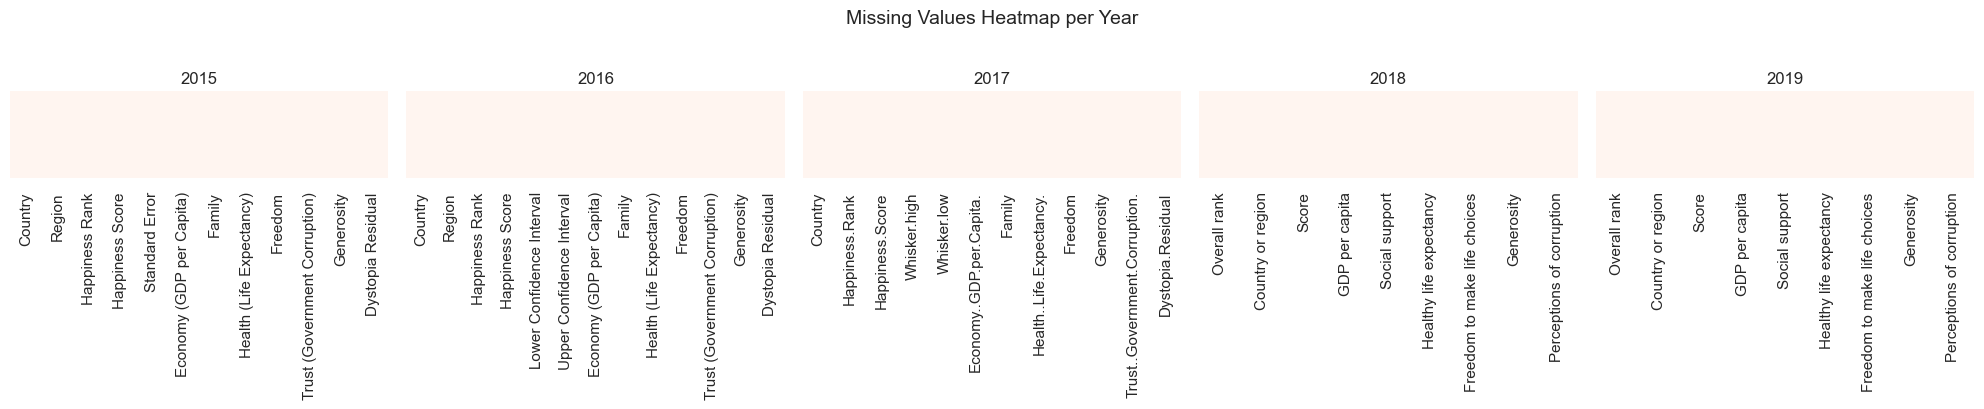

In [7]:
# ------------------------------------------------------------------
# Visual heatmap of missing values per year
# ------------------------------------------------------------------
fig, axes = plt.subplots(1, 5, figsize=(20, 4))

for ax, (year, df) in zip(axes, datasets.items()):
    sns.heatmap(
        df.isnull(),
        ax=ax,
        cbar=False,
        yticklabels=False,
        cmap='Reds'
    )
    ax.set_title(year)

plt.suptitle('Missing Values Heatmap per Year', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## 6. Duplicate Records

In [8]:
# ------------------------------------------------------------------
# Check for fully duplicated rows
# ------------------------------------------------------------------
for year, df in datasets.items():
    dupes = df.duplicated().sum()
    status = '✅ No duplicates' if dupes == 0 else f'⚠️ {dupes} duplicate(s) found'
    print(f'{year}: {status}')

2015: ✅ No duplicates
2016: ✅ No duplicates
2017: ✅ No duplicates
2018: ✅ No duplicates
2019: ✅ No duplicates


## 7. Descriptive Statistics

In [9]:
# ------------------------------------------------------------------
# Describe numeric columns for each year
# ------------------------------------------------------------------
for year, df in datasets.items():
    print(f'\n========== {year} ==========')
    display(df.describe().round(3))


========== 2015 ==========


,Happiness Rank,Happiness Score,Standard Error,Economy (GDP per Capita),Family,Health (Life Expectancy),Freedom,Trust (Government Corruption),Generosity,Dystopia Residual
count,158.000,158.000,158.000,158.000,158.000,158.000,158.000,158.000,158.000,158.000
mean,79.494,5.376,0.048,0.846,0.991,0.630,0.429,0.143,0.237,2.099
std,45.754,1.145,0.017,0.403,0.272,0.247,0.151,0.120,0.127,0.554
min,1.000,2.839,0.018,0.000,0.000,0.000,0.000,0.000,0.000,0.329
25%,40.250,4.526,0.037,0.546,0.857,0.439,0.328,0.062,0.151,1.759
50%,79.500,5.232,0.044,0.910,1.030,0.697,0.436,0.107,0.216,2.095
75%,118.750,6.244,0.052,1.158,1.214,0.811,0.549,0.180,0.310,2.462
max,158.000,7.587,0.137,1.690,1.402,1.025,0.670,0.552,0.796,3.602



========== 2016 ==========


,Happiness Rank,Happiness Score,Lower Confidence Interval,Upper Confidence Interval,Economy (GDP per Capita),Family,Health (Life Expectancy),Freedom,Trust (Government Corruption),Generosity,Dystopia Residual
count,157.000,157.000,157.000,157.000,157.000,157.000,157.000,157.000,157.000,157.000,157.000
mean,78.981,5.382,5.282,5.482,0.954,0.794,0.558,0.371,0.138,0.243,2.326
std,45.466,1.142,1.148,1.136,0.413,0.267,0.229,0.146,0.111,0.134,0.542
min,1.000,2.905,2.732,3.078,0.000,0.000,0.000,0.000,0.000,0.000,0.818
25%,40.000,4.404,4.327,4.465,0.670,0.642,0.383,0.257,0.061,0.155,2.032
50%,79.000,5.314,5.237,5.419,1.028,0.841,0.597,0.397,0.105,0.222,2.291
75%,118.000,6.269,6.154,6.434,1.280,1.022,0.730,0.485,0.176,0.312,2.665
max,157.000,7.526,7.460,7.669,1.824,1.183,0.953,0.608,0.505,0.820,3.838



========== 2017 ==========


,Happiness.Rank,Happiness.Score,Whisker.high,Whisker.low,Economy..GDP.per.Capita.,Family,Health..Life.Expectancy.,Freedom,Generosity,Trust..Government.Corruption.,Dystopia.Residual
count,155.000,155.000,155.000,155.000,155.000,155.000,155.000,155.000,155.000,155.000,155.000
mean,78.000,5.354,5.452,5.256,0.985,1.189,0.551,0.409,0.247,0.123,1.850
std,44.889,1.131,1.119,1.145,0.421,0.287,0.237,0.150,0.135,0.102,0.500
min,1.000,2.693,2.865,2.521,0.000,0.000,0.000,0.000,0.000,0.000,0.378
25%,39.500,4.506,4.608,4.375,0.663,1.043,0.370,0.304,0.154,0.057,1.591
50%,78.000,5.279,5.370,5.193,1.065,1.254,0.606,0.437,0.232,0.090,1.833
75%,116.500,6.102,6.195,6.007,1.318,1.414,0.723,0.517,0.324,0.153,2.145
max,155.000,7.537,7.622,7.480,1.871,1.611,0.949,0.658,0.838,0.464,3.117



========== 2018 ==========


,Overall rank,Score,GDP per capita,Social support,Healthy life expectancy,Freedom to make life choices,Generosity,Perceptions of corruption
count,156.000,156.000,156.000,156.000,156.000,156.000,156.000,155.000
mean,78.500,5.376,0.891,1.213,0.597,0.455,0.181,0.112
std,45.177,1.120,0.392,0.302,0.248,0.162,0.098,0.096
min,1.000,2.905,0.000,0.000,0.000,0.000,0.000,0.000
25%,39.750,4.454,0.616,1.067,0.422,0.356,0.110,0.051
50%,78.500,5.378,0.950,1.255,0.644,0.487,0.174,0.082
75%,117.250,6.168,1.198,1.463,0.777,0.578,0.239,0.137
max,156.000,7.632,2.096,1.644,1.030,0.724,0.598,0.457



========== 2019 ==========


,Overall rank,Score,GDP per capita,Social support,Healthy life expectancy,Freedom to make life choices,Generosity,Perceptions of corruption
count,156.000,156.000,156.000,156.000,156.000,156.000,156.000,156.000
mean,78.500,5.407,0.905,1.209,0.725,0.393,0.185,0.111
std,45.177,1.113,0.398,0.299,0.242,0.143,0.095,0.095
min,1.000,2.853,0.000,0.000,0.000,0.000,0.000,0.000
25%,39.750,4.544,0.603,1.056,0.548,0.308,0.109,0.047
50%,78.500,5.380,0.960,1.272,0.789,0.417,0.178,0.085
75%,117.250,6.184,1.233,1.452,0.882,0.507,0.248,0.141
max,156.000,7.769,1.684,1.624,1.141,0.631,0.566,0.453


## 8. Happiness Score Distribution per Year

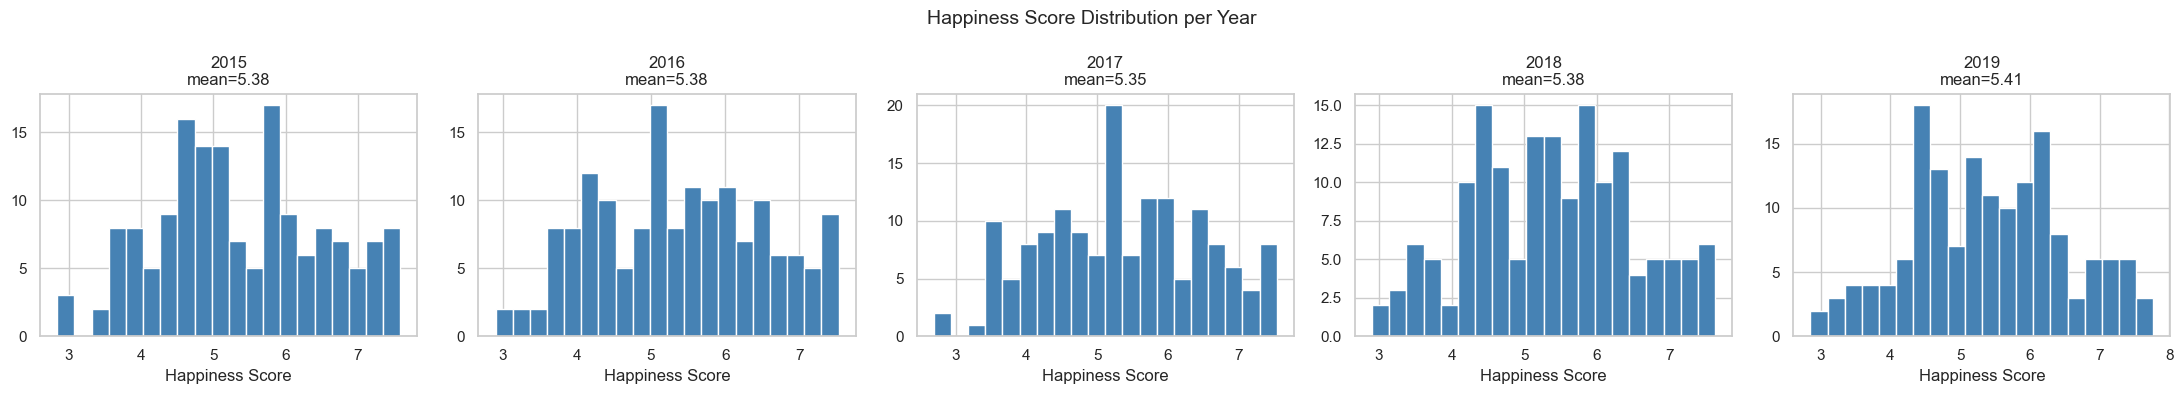

In [10]:
# ------------------------------------------------------------------
# Map each year to the correct column name for happiness score
# ------------------------------------------------------------------
score_col = {
    '2015': 'Happiness Score',
    '2016': 'Happiness Score',
    '2017': 'Happiness.Score',
    '2018': 'Score',
    '2019': 'Score',
}

fig, axes = plt.subplots(1, 5, figsize=(22, 4), sharey=False)

for ax, (year, df) in zip(axes, datasets.items()):
    col = score_col[year]
    ax.hist(df[col], bins=20, color='steelblue', edgecolor='white')
    ax.set_title(f'{year}\nmean={df[col].mean():.2f}')
    ax.set_xlabel('Happiness Score')

plt.suptitle('Happiness Score Distribution per Year', fontsize=14)
plt.tight_layout()
plt.show()

## 9. Outlier Detection — Boxplots

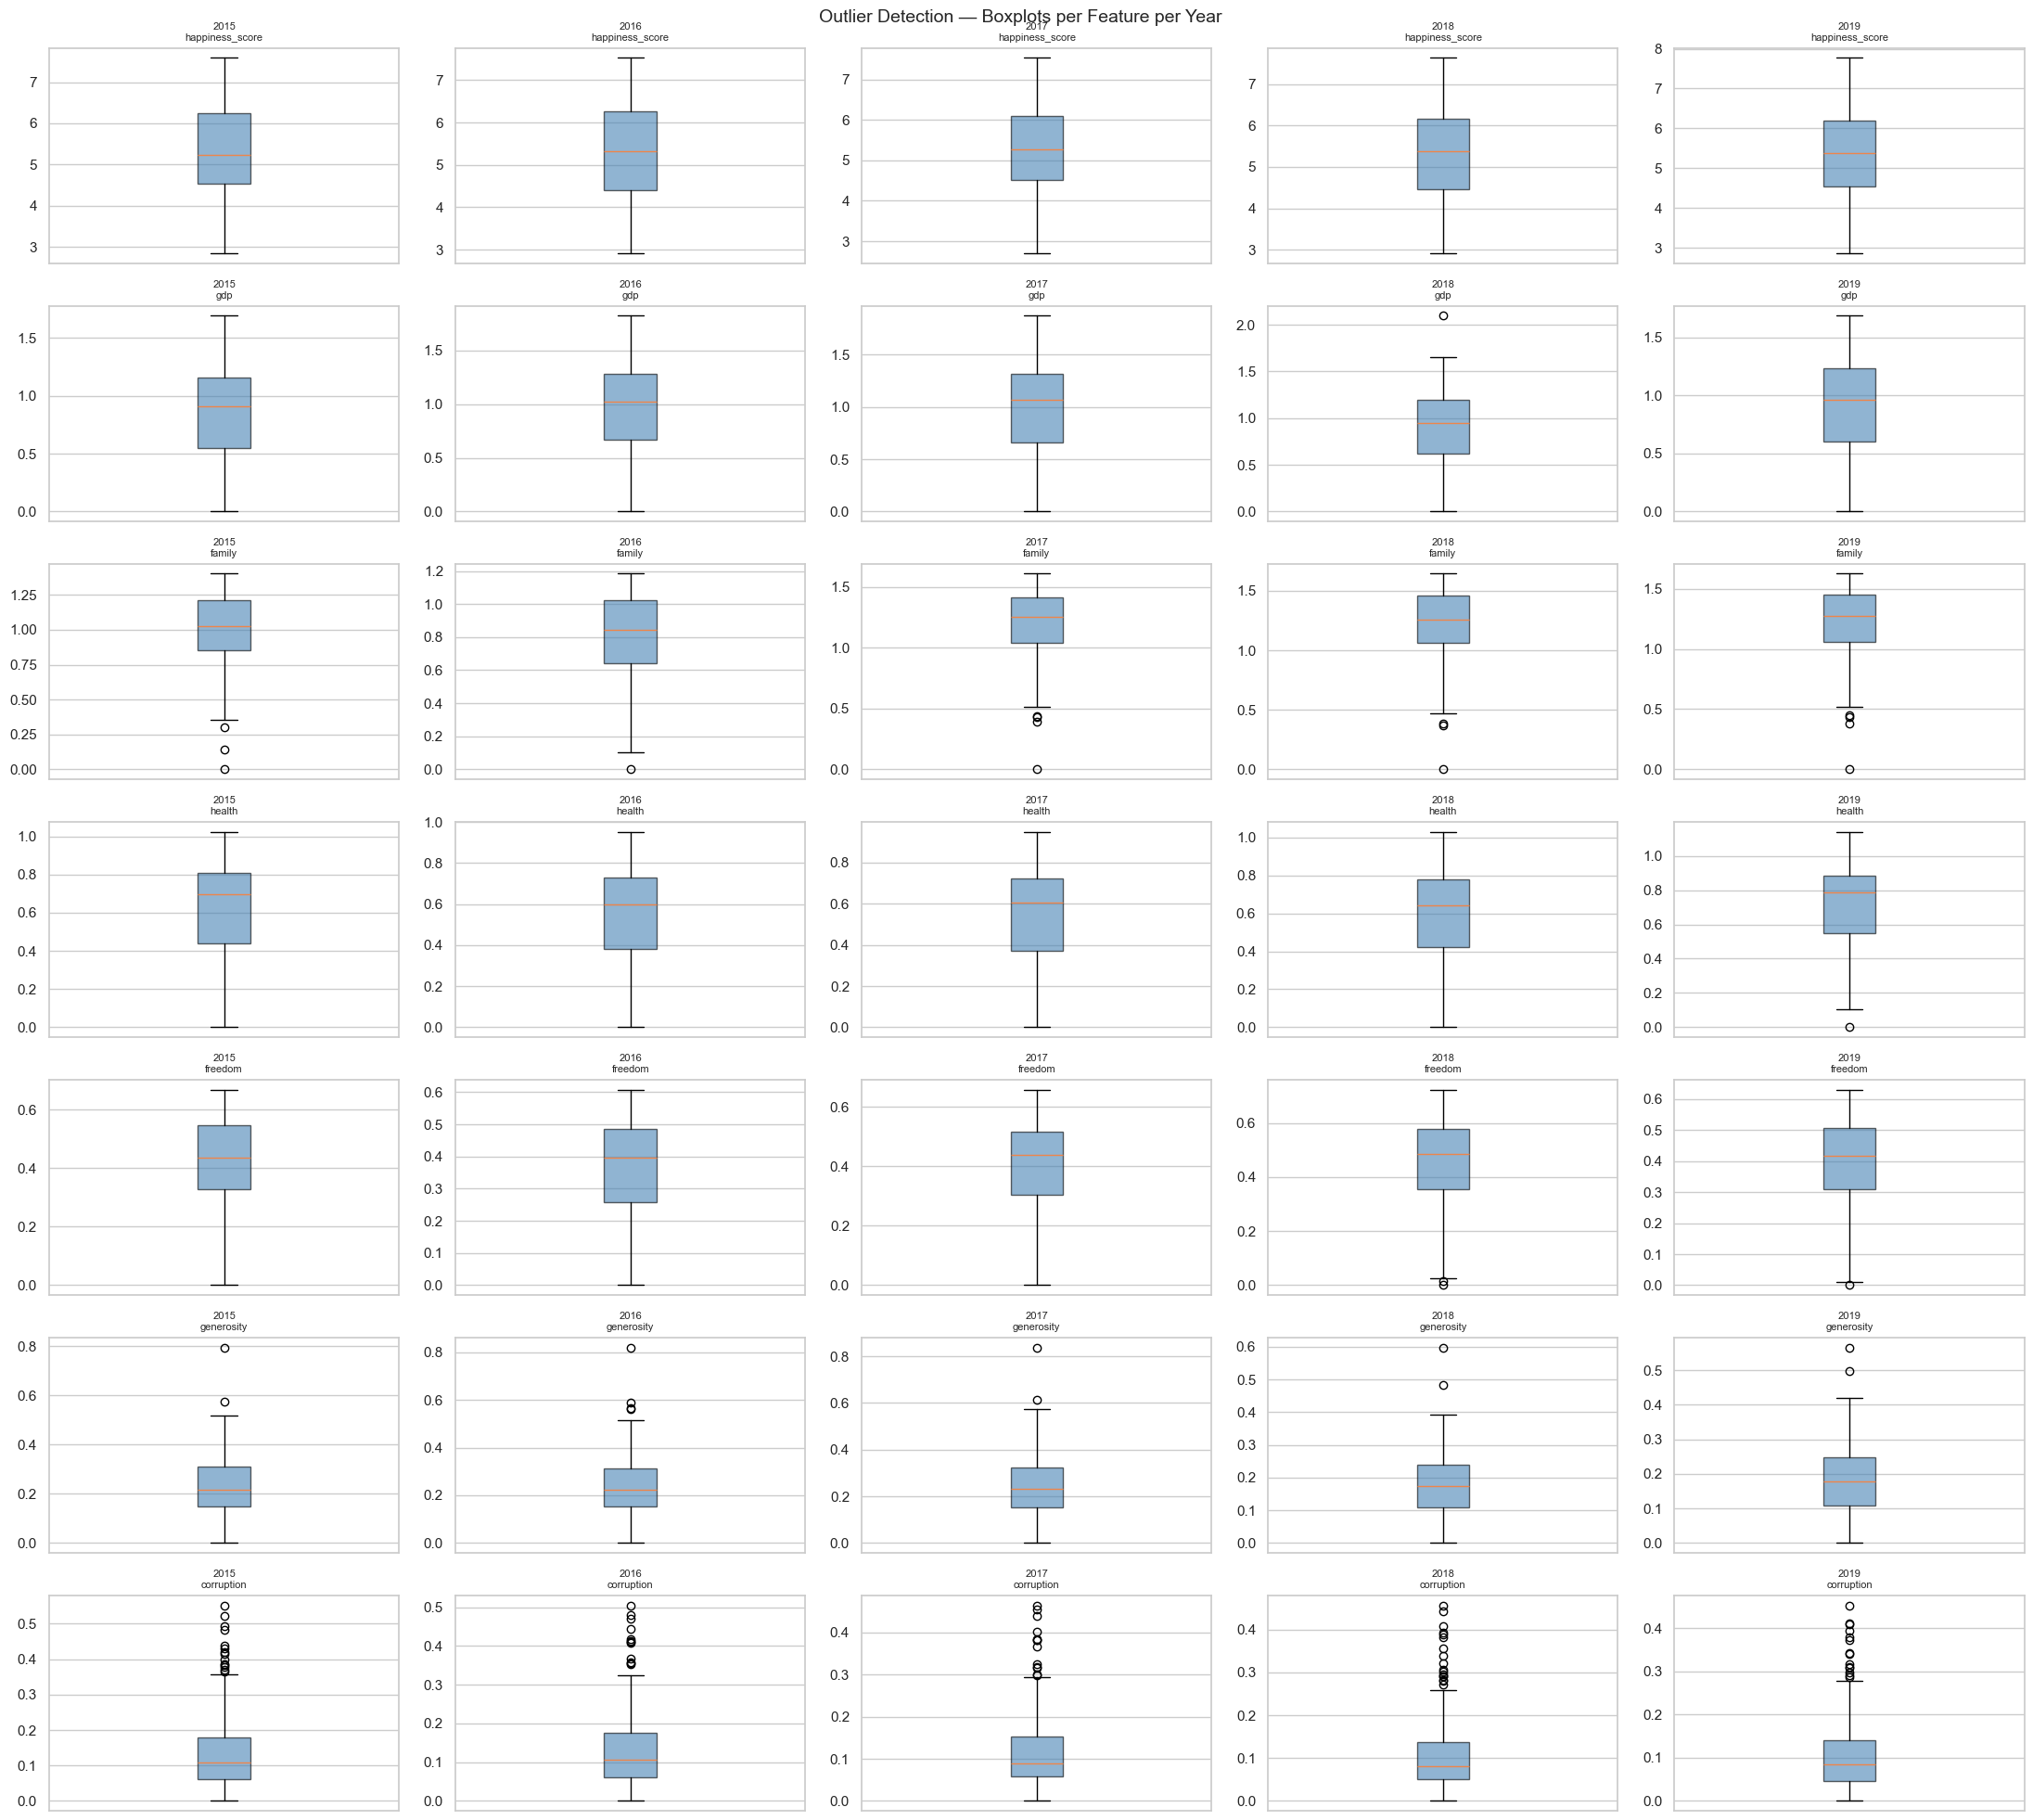

In [11]:
# ------------------------------------------------------------------
# Common numeric features mapped per year
# ------------------------------------------------------------------
feature_map = {
    '2015': {
        'happiness_score': 'Happiness Score',
        'gdp':             'Economy (GDP per Capita)',
        'family':          'Family',
        'health':          'Health (Life Expectancy)',
        'freedom':         'Freedom',
        'generosity':      'Generosity',
        'corruption':      'Trust (Government Corruption)',
    },
    '2016': {
        'happiness_score': 'Happiness Score',
        'gdp':             'Economy (GDP per Capita)',
        'family':          'Family',
        'health':          'Health (Life Expectancy)',
        'freedom':         'Freedom',
        'generosity':      'Generosity',
        'corruption':      'Trust (Government Corruption)',
    },
    '2017': {
        'happiness_score': 'Happiness.Score',
        'gdp':             'Economy..GDP.per.Capita.',
        'family':          'Family',
        'health':          'Health..Life.Expectancy.',
        'freedom':         'Freedom',
        'generosity':      'Generosity',
        'corruption':      'Trust..Government.Corruption.',
    },
    '2018': {
        'happiness_score': 'Score',
        'gdp':             'GDP per capita',
        'family':          'Social support',
        'health':          'Healthy life expectancy',
        'freedom':         'Freedom to make life choices',
        'generosity':      'Generosity',
        'corruption':      'Perceptions of corruption',
    },
    '2019': {
        'happiness_score': 'Score',
        'gdp':             'GDP per capita',
        'family':          'Social support',
        'health':          'Healthy life expectancy',
        'freedom':         'Freedom to make life choices',
        'generosity':      'Generosity',
        'corruption':      'Perceptions of corruption',
    },
}

features_to_plot = ['happiness_score', 'gdp', 'family', 'health', 'freedom', 'generosity', 'corruption']

fig, axes = plt.subplots(len(features_to_plot), 5, figsize=(22, 20))

for row_idx, feat in enumerate(features_to_plot):
    for col_idx, (year, df) in enumerate(datasets.items()):
        col = feature_map[year][feat]
        axes[row_idx, col_idx].boxplot(df[col].dropna(), patch_artist=True,
                                        boxprops=dict(facecolor='steelblue', alpha=0.6))
        axes[row_idx, col_idx].set_title(f'{year}\n{feat}', fontsize=8)
        axes[row_idx, col_idx].set_xticks([])

plt.suptitle('Outlier Detection — Boxplots per Feature per Year', fontsize=14)
plt.tight_layout()
plt.show()

## 10. Correlation Heatmap per Year

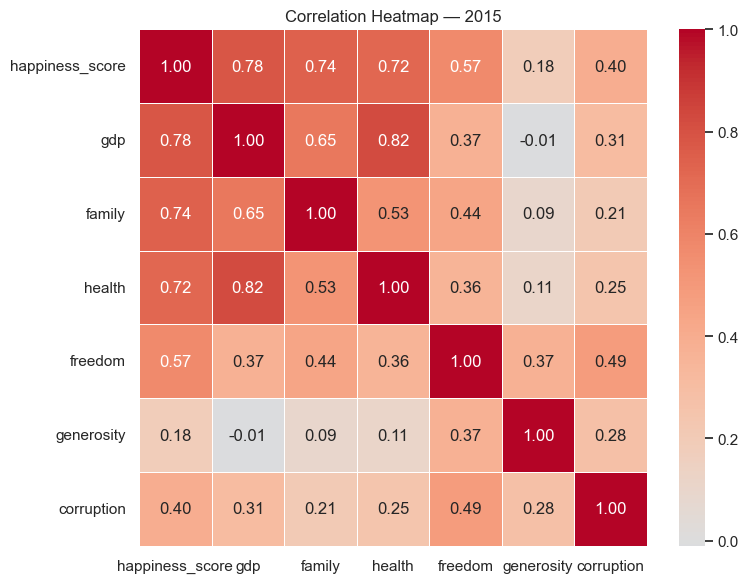

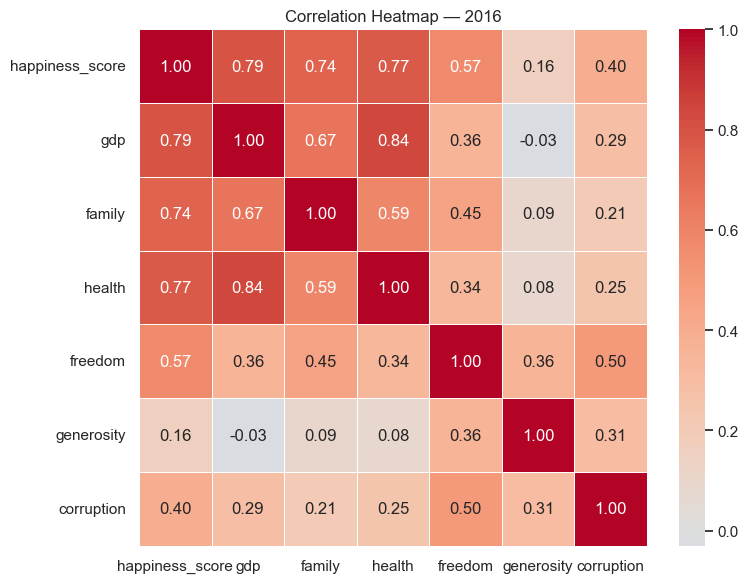

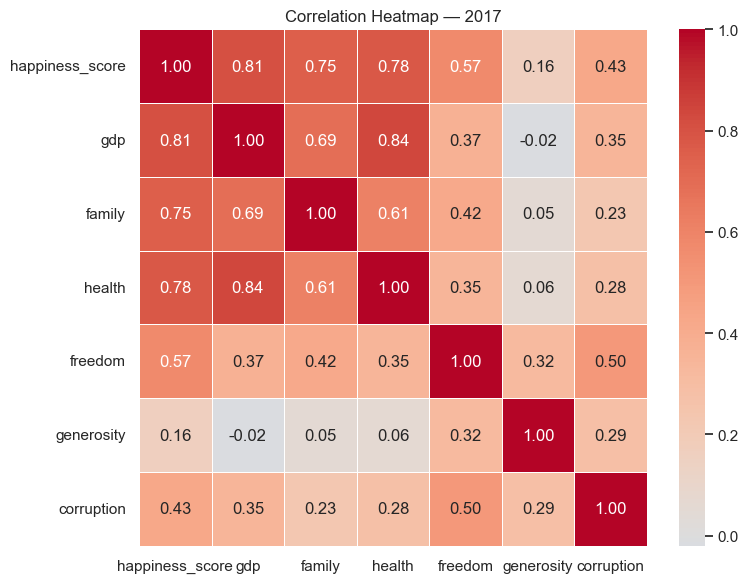

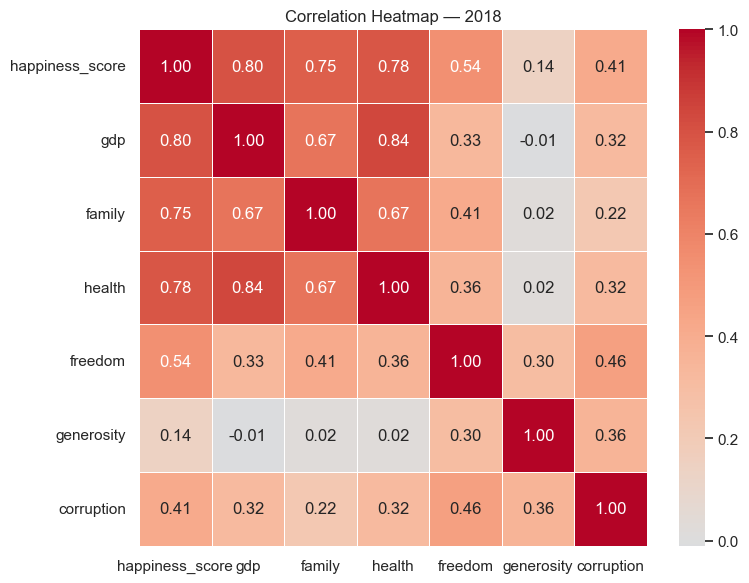

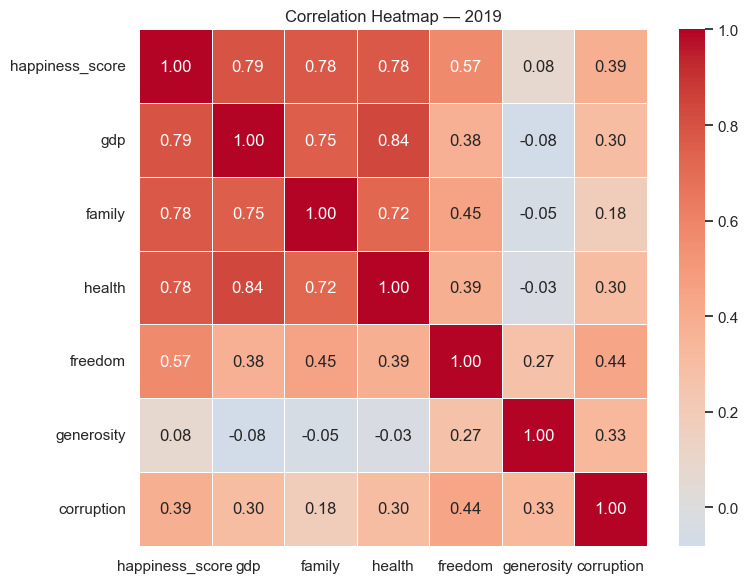

In [12]:
# ------------------------------------------------------------------
# Correlation matrix using the mapped feature names
# ------------------------------------------------------------------
for year, df in datasets.items():
    cols = list(feature_map[year].values())
    corr = df[cols].corr().round(2)

    # Rename columns/index to unified names for readability
    unified_names = list(feature_map[year].keys())
    corr.columns = unified_names
    corr.index = unified_names

    plt.figure(figsize=(8, 6))
    sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, linewidths=0.5)
    plt.title(f'Correlation Heatmap — {year}')
    plt.tight_layout()
    plt.show()

## 11. Top 10 and Bottom 10 Countries by Happiness Score (2019)

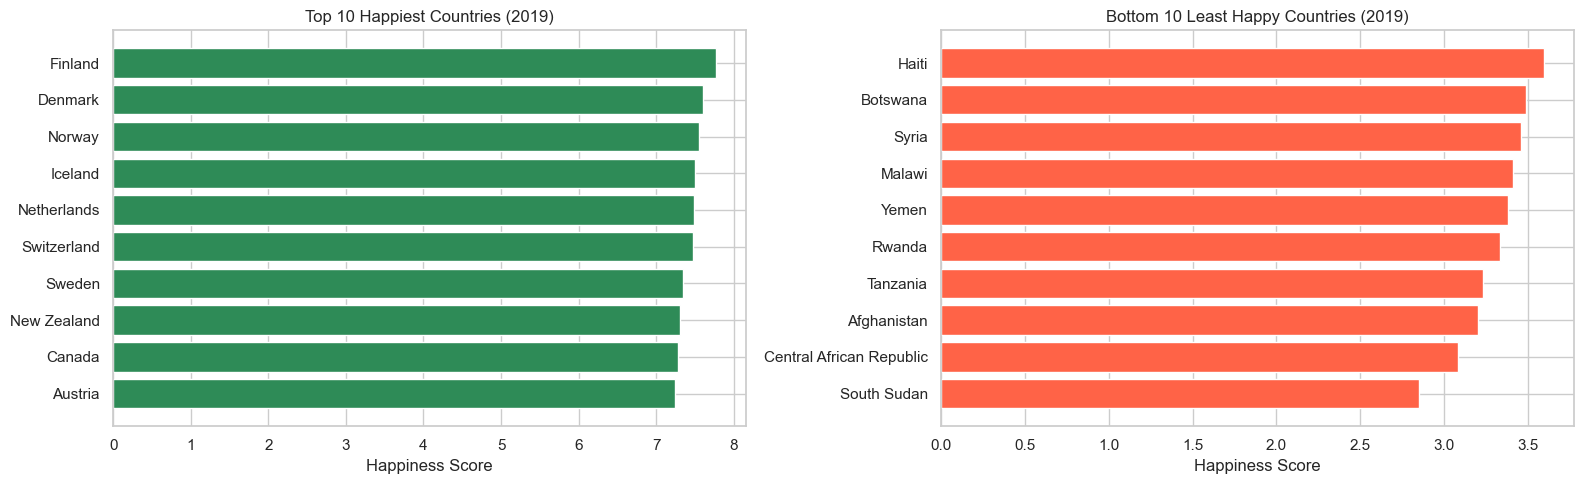

In [13]:
# ------------------------------------------------------------------
# Use 2019 as reference year for ranking visualization
# ------------------------------------------------------------------
df_ref = df_2019.copy()
df_ref = df_ref.sort_values('Score', ascending=False)

top10    = df_ref.head(10)
bottom10 = df_ref.tail(10)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].barh(top10['Country or region'][::-1], top10['Score'][::-1], color='seagreen')
axes[0].set_title('Top 10 Happiest Countries (2019)')
axes[0].set_xlabel('Happiness Score')

axes[1].barh(bottom10['Country or region'][::-1], bottom10['Score'][::-1], color='tomato')
axes[1].set_title('Bottom 10 Least Happy Countries (2019)')
axes[1].set_xlabel('Happiness Score')

plt.tight_layout()
plt.show()

## 12. Summary of Data Quality Observations

In [14]:
# ------------------------------------------------------------------
# Print a structured quality summary
# ------------------------------------------------------------------
observations = {
    'Schema inconsistencies': [
        '2015/2016: column names use spaces (e.g. Happiness Score)',
        '2017: column names use dot notation (e.g. Happiness.Score)',
        '2018/2019: column names use plain lowercase with spaces',
        '2017, 2018, 2019: no Region column present',
        '2015/2016 have extra columns: Dystopia Residual, Confidence Intervals',
    ],
    'Missing values': [
        '2018: 1 null in Perceptions of corruption — to be filled with median or dropped',
        'All other years: no missing values',
    ],
    'Duplicates': [
        'No duplicate rows found in any year',
    ],
    'Proposed unified schema (after cleaning)': [
        'country, year, happiness_score, gdp, family, health, freedom, generosity, corruption',
    ],
    'Columns to drop (not needed for ML)': [
        'Happiness Rank / Overall rank',
        'Standard Error',
        'Dystopia Residual',
        'Whisker.high / Whisker.low',
        'Lower/Upper Confidence Interval',
        'Region (only present in 2 years)',
    ],
}

for category, points in observations.items():
    print(f'\n🔹 {category}')
    for p in points:
        print(f'   - {p}')


🔹 Schema inconsistencies
   - 2015/2016: column names use spaces (e.g. Happiness Score)
   - 2017: column names use dot notation (e.g. Happiness.Score)
   - 2018/2019: column names use plain lowercase with spaces
   - 2017, 2018, 2019: no Region column present
   - 2015/2016 have extra columns: Dystopia Residual, Confidence Intervals

🔹 Missing values
   - 2018: 1 null in Perceptions of corruption — to be filled with median or dropped
   - All other years: no missing values

🔹 Duplicates
   - No duplicate rows found in any year

🔹 Proposed unified schema (after cleaning)
   - country, year, happiness_score, gdp, family, health, freedom, generosity, corruption

🔹 Columns to drop (not needed for ML)
   - Happiness Rank / Overall rank
   - Standard Error
   - Dystopia Residual
   - Whisker.high / Whisker.low
   - Lower/Upper Confidence Interval
   - Region (only present in 2 years)
